## Step 1: Data Loading and Initial Exploration
1. Load all datasets using Pandas 
2. Inspect structure using .head(), .info(), .describe() 
3. Identify primary and foreign keys 
4. Understand relationships between tables

In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Read all the csv files and load it into dataframes

# Contains customer demographic and location information 
customer_df = pd.read_csv("dataset/customers.csv")

#Contains order lifecycle details (purchase, delivery, timestamps) - Info central to the system
orders_df = pd.read_csv("dataset/orders.csv")

#Contains product-level details for each order 
order_items_df = pd.read_csv("dataset/order_item.csv")

# Payment information including type and value 
payments_df = pd.read_csv("dataset/payments.csv")

# Customer feedback and review scores
reviews_df = pd.read_csv("dataset/reviews.csv")

# Product details and categories 
products_df = pd.read_csv("dataset/products.csv")

# Seller-level information
sellers_df = pd.read_csv("dataset/sellers.csv")

# Geographic information 
geoloc_df = pd.read_csv("dataset/location.csv")

# Mapping of product categories to English names 
cat_trans_df = pd.read_csv("dataset/category_translation.csv")

In [ ]:
# Analyze customer info
# customer_df.shape
# customer_df.info()
print(customer_df.head(n=3))
print("Is customer_id unique?",customer_df['customer_id'].is_unique)
print("Is customer_unique_id unique?",customer_df['customer_unique_id'].is_unique)

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
Is customer_id unique? True
Is customer_unique_id unique? False


### Initial analysis of customer data
1. The customer has 99441 rows and 5 columns
2. No columns have null values - good data quality
3. customer_id is the unique column something like a uuid generated for each order,so it can be used to join with the order table.
4. customer_unique_id contains duplicate values i.e these are the ids used to uniquely identify a customer but can have duplicate values as one customer can place multiple orders.
5. customer_id actually gives cutomer-order relationship.

In [ ]:
# Analyze orders info
# orders_df.shape
# orders_df.info()
print(orders_df.head(n=3))
print("Is customer_id unique?",orders_df['customer_id'].is_unique)
print("Is order_id unique?",orders_df['order_id'].is_unique)

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2          2018-08-08 13:50:00           2018-08-17 18:06:29   

  order_estimated_delivery_date  
0           2017-10-18 00:00:00  
1           2018-08-13 00:00:00  
2           2018-09-04 00:00:00  
Is customer_id unique? True
Is order_id unique? True


### Inital Analysis of order data
1. The order table has 99441 rows and 8 columns.
2. The order table has customer_id which is a foreign key in orders table and primary key in customer table 
3. Some fields have null values should be explored later.
4. All the fields are objects the dates can be converted to timestamps.

In [ ]:
# Analyze order_item info

# order_items_df.shape
# order_items_df.info()
print(order_items_df.head(n=3))

print("Is order_id unique in order_item table:",order_items_df["order_id"].is_unique)
order_dup = order_items_df[order_items_df.duplicated(subset="order_id",keep=False)]
# print("Duplicates:",order_dup.sort_values(by="order_id").head())

                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   

   shipping_limit_date  price  freight_value  
0  2017-09-19 09:45:35   58.9          13.29  
1  2017-05-03 11:05:13  239.9          19.93  
2  2018-01-18 14:48:30  199.0          17.87  
Is order_id unique in order_item table: False


### Inital Analysis of order_item data
1. The order table has 112650 rows and 7 columns.
2. The data is more that order table.
3. As there is product and seller id in the order_item table I am analyzing those two tables along with order_item

In [ ]:
# Analysis of products
# products_df.shape
# products_df.info()
products_df.head()
print("Is product ID unique in product table?",products_df['product_id'].is_unique)
print("Is product ID unique in order_item table?",order_items_df['product_id'].is_unique)

Is product ID unique in product table? True
Is product ID unique in order_item table? False


In [ ]:
# Analysis of seller table
# print(sellers_df.shape)
# print(sellers_df.info())
print(sellers_df.head(n=2))
print("Is seller ID unique in seller table?",sellers_df['seller_id'].is_unique)
print("Is seller ID unique in order_item table?",order_items_df['seller_id'].is_unique)

                          seller_id  seller_zip_code_prefix seller_city  \
0  3442f8959a84dea7ee197c632cb2df15                   13023    campinas   
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844  mogi guacu   

  seller_state  
0           SP  
1           SP  
Is seller ID unique in seller table? True
Is seller ID unique in order_item table? False


### Combined Analysis of product, seller and order_info table
1. The order_item table is an intermediate table which handles the many-to-many relationships between the order+item/product and order+item/seller. 
2. One order can have many products and one product can be present in many orders.Also order can be sold by multiple sellers and a seller can have multiple orders.
3. In an intermediate table we cannot identify a row using a single column like order_id/seller_id or order_item id because from the data it is clear that both are not unique.
4. Uniqueness can be obtained by a combination of order_id + order_item_id in order_items table

In [ ]:
# Analyze payments info

# print(payments_df.shape)
# print(payments_df.info())
# print(payments_df.head())

print(payments_df['order_id'].is_unique)

payments_dup = payments_df[payments_df.duplicated(subset="order_id",keep=False)]

payments_dup = payments_dup.sort_values(by="order_id")
print(payments_dup.head(n=3))

False
                               order_id  payment_sequential payment_type  \
80856  0016dfedd97fc2950e388d2971d718c7                   2      voucher   
89575  0016dfedd97fc2950e388d2971d718c7                   1  credit_card   
20036  002f19a65a2ddd70a090297872e6d64e                   1      voucher   

       payment_installments  payment_value  
80856                     1          17.92  
89575                     5          52.63  
20036                     1          44.11  


### Inital Analysis of payments data
1. The payments dataframe has 103886 rows and 5 columns.The data is more than that of order table.
2. As the order_id is duplicate it means one order_id can be paid using more than 1 payment type.
3. Here order and the payment have a one is to many relationship so direct join is not possible.

In [ ]:
# Analysis of reviews
# print(reviews_df.shape)
# print(reviews_df.head())
# print(reviews_df.info())

print(reviews_df['review_id'].is_unique)
print(reviews_df['order_id'].is_unique)

review_dup = reviews_df[reviews_df.duplicated(subset="review_id",keep=False)]
review_dup.sort_values(by="review_id").head()

order_dup = reviews_df[reviews_df.duplicated(subset="order_id",keep=False)]
order_dup.sort_values(by="order_id").head()

False
False


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06


### Inital Analysis of review data
1. The payments dataframe has 99224 rows and 7 columns.The data is less than that of order table.
2. Some orders do not have reviews
3. The order_id and review_id is not unique (Why?)
4. One order can have multiple reviews but how can one review be part of multiple orders?
5. Is this not a data quality issue?
6. Planning to focus on order id

In [ ]:
# Analysis of geolocation
geoloc_df.shape
geoloc_df.head()
# print(geoloc_df.info())

print(geoloc_df["geolocation_zip_code_prefix"].is_unique)

False


In [ ]:
# Analysis of category transalation
cat_trans_df.shape
cat_trans_df.head(n=2)
# print(cat_trans_df.info())

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories


## Step 2: Data Cleaning and Preprocessing
1. Handle missing values appropriately 
2. Remove duplicate records 
3. Convert date columns to datetime format 
4. Validate data types and ranges 
5. Standardize column names if required 

### Handle missing values appropriately

In [ ]:
customer_df.shape
print(customer_df.isnull().sum())

#The customer_df does not have any null values.

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [ ]:
print(orders_df.isnull().sum())
print("Shape",orders_df.shape)
# print(orders_df.info())
# The order_approved_at is null - Order not approved
orders_df[orders_df["order_approved_at"].isnull()]["order_status"].value_counts()

# The order_delivered_carrier_date is null - Order not delivered to vendor
orders_df[orders_df["order_delivered_carrier_date"].isnull()]["order_status"].value_counts()

# The order_delivered_carrier_date is null - Order not delivered to customer
orders_df[orders_df["order_delivered_customer_date"].isnull()]["order_status"].value_counts()

# Even if the order_approved_at and order_delivered_customer_date is NULL we can check if the order is delivered or not using the order_delivered_customer_date

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Shape (99441, 8)


shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: order_status, dtype: int64

In [ ]:
order_items_df.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [ ]:
payments_df.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [ ]:
reviews_df.isnull().sum()
# Here review comment title and message are missing, which means only ratings are given for many reviews
reviews_df.shape

# More than half of the data is null
reviews_df = reviews_df.drop(columns=["review_comment_title","review_comment_message"])

In [ ]:
print(products_df.isnull().sum())
#product_category_name,product_name_lenght,product_description_lenght,product_photos_qty all have equal number of missing rows
#product_weight_g,product_length_cm,product_height_cm,product_width_cm

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [ ]:
# Check how many products with the above characteristics are in order_items df
# Find rows where all 4 columns are NULL in the same row 
cols = ["product_category_name","product_name_lenght","product_description_lenght","product_photos_qty"]
null_rows = products_df[products_df[cols].isnull().all(axis=1)]
print(null_rows.shape)
#Null _rows equals missing values
missing_product_ids = null_rows["product_id"]
print("Products with missing characteristics in order_item",order_items_df[order_items_df["product_id"].isin(missing_product_ids)].shape)
print(order_items_df.shape)

(610, 9)
Products with missing characteristics in order_item (1603, 7)
(112650, 7)


In [ ]:
cols = ["product_weight_g","product_length_cm","product_height_cm","product_width_cm"]
null_dim_rows = products_df[products_df[cols].isnull().all(axis=1)]
print(null_dim_rows.shape)
missing_dim_product_ids = null_dim_rows["product_id"]
print("Products with all the values missing",null_rows[null_rows["product_id"].isin(missing_dim_product_ids)].shape)
print("Products with missing dimension values in order_item df",order_items_df[order_items_df["product_id"].isin(missing_dim_product_ids)].shape)

(2, 9)
Products with all the values missing (1, 9)
Products with missing dimension values in order_item df (18, 7)


In [ ]:
# Have decided to drop the rows from product
print(products_df.shape)
products_df = products_df.dropna(subset=["product_category_name"])
print(products_df.shape)

(32951, 9)
(32341, 9)


In [ ]:
products_df = products_df.dropna(subset=["product_weight_g"])
print(products_df.shape)

(32340, 9)


In [ ]:
print(sellers_df.isnull().sum())

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


In [ ]:
print(geoloc_df.isnull().sum())

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


In [ ]:
print(cat_trans_df.isnull().sum())

product_category_name            0
product_category_name_english    0
dtype: int64


### Remove duplicate records

In [ ]:
customer_df[customer_df.duplicated()]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


In [ ]:
orders_df[orders_df.duplicated()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


In [ ]:
order_items_df[order_items_df.duplicated()]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [ ]:
payments_df[payments_df.duplicated()]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [ ]:
reviews_df[reviews_df.duplicated()]

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp


In [ ]:
products_df[products_df.duplicated()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [ ]:
sellers_df[sellers_df.duplicated()]

,seller_id,seller_zip_code_prefix,seller_city,seller_state


In [ ]:
geoloc_df[geoloc_df.duplicated()].head(n=2)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.64482,sao paulo,SP
44,1046,-23.546081,-46.64482,sao paulo,SP


In [ ]:
print(geoloc_df.shape)
geoloc_df = geoloc_df.drop_duplicates()
print(geoloc_df.shape)

# Since these are true duplicates all values for all the columns are same so dropping them

(1000163, 5)
(738332, 5)


In [ ]:
cat_trans_df[cat_trans_df.duplicated()]

,product_category_name,product_category_name_english


### Convert date columns to datetime format 

In [ ]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
orders_df[date_cols] = orders_df[date_cols].apply(pd.to_datetime)

In [ ]:
order_items_df["shipping_limit_date"] = order_items_df["shipping_limit_date"].apply(pd.to_datetime)
order_items_df.dtypes

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

In [ ]:
reviews_df["review_creation_date"] = reviews_df["review_creation_date"].apply(pd.to_datetime)
reviews_df.dtypes

review_id                          object
order_id                           object
review_score                        int64
review_creation_date       datetime64[ns]
review_answer_timestamp            object
dtype: object

### Validate data types and ranges

In [ ]:
print("Negative Price",order_items_df[order_items_df["price"]<0].shape)
print("Negative Freight Value",order_items_df[order_items_df["freight_value"]<0].shape)

Negative Price (0, 7)
Negative Freight Value (0, 7)


In [ ]:
print("Negative payment value",payments_df[payments_df["payment_value"]<0].shape)

Negative payment value (0, 5)


In [ ]:
print(reviews_df["review_score"].unique()) # No outliers

[4 5 1 3 2]


### Standardize column names if required

In [ ]:
orders_df = orders_df.rename(columns={
    "order_purchase_timestamp": "order_purchased_at",
})

In [ ]:
products_df = products_df.rename(columns={
    "product_name_lenght": "product_name_length",
    "product_description_lenght": "product_description_length",
    "product_weight_g": "product_weight_gram",
    
})
products_df.head()

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_gram,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


## Step 3: Data Integration (Critical Component)
You must construct a Master Dataset by merging multiple tables.
Recommended sequence:
1. orders + customers 
2. orders + order_items 
3. order_items + products 
4. orders + payments 
5. orders + reviews 
6. order_items + sellers 
7. products + category_translation


Final output:
A single consolidated dataset representing a unified business view

In [ ]:
# orders + customers - straight forward
df = orders_df.merge(
    customer_df,
    on="customer_id",
    how="left"
)

df = df.merge(
    order_items_df,
    on="order_id",
    how="left"
)

df = df.merge(
    products_df,
    on="product_id",
    how="left"
)

df = df.merge(
    payments_df,
    on="order_id",
    how="left"
)

df = df.merge(
    reviews_df,
    on="order_id",
    how="left"
)

df = df.merge(
    sellers_df,
    on="seller_id",
    how="left"
)

df = df.merge(
    cat_trans_df,
    on="product_category_name",
    how="left"
)

## Step 4: Feature Engineering
Create meaningful features such as:
1. Total order value (aggregated from order_items or payments) 
2. Delivery time (order purchase to delivery date) 
3. Number of items per order 
4. Customer purchase frequency 
5. Customer lifetime value (basic approximation) 
6. Average order value per customer 

In [ ]:
df["item_total"] = df["price"] + df["freight_value"]
df.head(n=2)

order_total = df.groupby("order_id", as_index=False).agg({
    "item_total": "sum"
}).rename(columns={"item_total": "total_order_value"})
order_total.head()

df = df.merge(order_total,on="order_id",how="left")
df.shape
df.head(n=2)

,order_id,customer_id,order_status,order_purchased_at,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_id,review_score,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,item_total,total_order_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,38.71,116.13
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,38.71,116.13


In [ ]:
df[df.duplicated(subset="order_id",keep=False)].head(n=3)

,order_id,customer_id,order_status,order_purchased_at,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_id,review_score,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,item_total,total_order_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,38.71,116.13
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,38.71,116.13
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,38.71,116.13


In [ ]:
# Delivery time 
df["delivery_days"] = (
    df["order_delivered_customer_date"] -
    df["order_purchased_at"]
).dt.days
df.head(n=3)

,order_id,customer_id,order_status,order_purchased_at,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_score,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,item_total,total_order_value,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,38.71,116.13,8.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,38.71,116.13,8.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,38.71,116.13,8.0


In [ ]:
# Number of items per order 
items_per_order = df.groupby("order_id", as_index=False).agg({
    "order_item_id": "count"
}).rename(columns={
    "order_item_id": "item_count"
})
items_per_order.head()
df = df.merge(items_per_order,on="order_id",how="left")
df.head()

,order_id,customer_id,order_status,order_purchased_at,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,item_total,total_order_value,delivery_days,item_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,38.71,116.13,8.0,3
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,38.71,116.13,8.0,3
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,38.71,116.13,8.0,3
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,2018-08-08,2018-08-08 18:37:50,31570.0,belo horizonte,SP,perfumery,141.46,141.46,13.0,1
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,2018-08-18,2018-08-22 19:07:58,14840.0,guariba,SP,auto,179.12,179.12,9.0,1


In [ ]:
# Customer purchase frequency 
# Count unique orders from the original order and customer tables to avoid merged-row duplication.
customer_orders_df = orders_df.merge(
    customer_df[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

purchase_frequency = customer_orders_df.groupby("customer_unique_id").agg({
    "order_id":"nunique"
}).reset_index().rename(columns={
    "order_id":"purchase_frequency"
})
purchase_frequency[purchase_frequency["purchase_frequency"]>1].head(n=2)
purchase_frequency.shape

In [ ]:
# Customer lifetime value (basic approximation) 
# Sum one total per unique order, then aggregate to customer level.
order_value_df = order_items_df.copy()
order_value_df["item_total"] = order_value_df["price"] + order_value_df["freight_value"]

order_value_df = (
    order_value_df.groupby("order_id", as_index=False)
    .agg(total_order_value=("item_total", "sum"))
)

order_customer_value_df = customer_orders_df.merge(
    order_value_df,
    on="order_id",
    how="left"
)

clv = order_customer_value_df.groupby("customer_unique_id").agg(
    {"total_order_value":"sum"}
).reset_index().rename(columns={
    "total_order_value":"clv"
})
clv.head()

In [ ]:
customer_info_df = clv.merge(purchase_frequency,on="customer_unique_id",how="left")

In [ ]:
customer_info_df.head(n=2)

,customer_unique_id,clv,purchase_frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1


In [ ]:
# Average order value per customer 
customer_info_df["aov"] = customer_info_df["clv"]/customer_info_df["purchase_frequency"]

In [ ]:
customer_info_df.head(n=2)

,customer_unique_id,clv,purchase_frequency,aov
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,27.19


## Step 5: Exploratory Data Analysis (EDA)
Perform structured analysis across the following dimensions:

1. Customer Analysis
    - New vs repeat customers 
    - High-value vs low-value customers 
    - Geographic distribution of customers 

2. Revenue and Order Analysis
    - Monthly revenue trends 
    - Order volume trends 
    - Peak sales periods 

3. Product Analysis
    - Top-selling product categories 
    - Revenue contribution by category 
    - Product demand distribution 

4. Seller Analysis
    - Top-performing sellers 
    - Seller contribution to revenue 
    - Seller distribution 

5. Review and Satisfaction Analysis
    - Distribution of review scores 
    - Relationship between delivery time and ratings 
    - Identification of dissatisfaction patterns 

### Customer Analysis

In [ ]:
print(customer_info_df.shape)
print(customer_df["customer_unique_id"].nunique())

(96096, 4)
96096


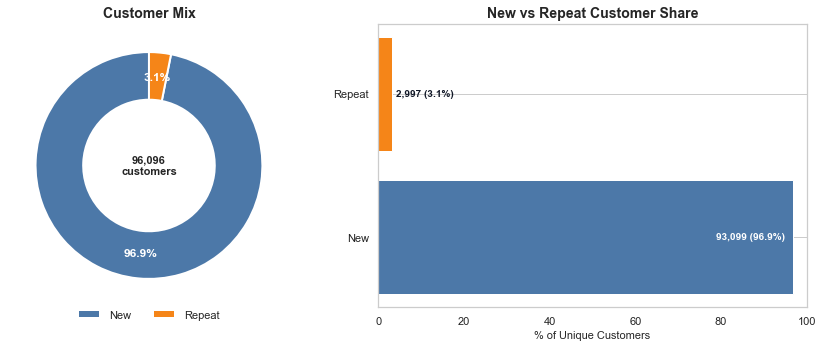

In [199]:
# New vs repeat customers
# Use original customer table so merged order-item/payment/review rows do not inflate repeat counts.
customer_order_counts = customer_df["customer_unique_id"].value_counts()
customer_type_summary = pd.DataFrame({
    "customer_type": ["New", "Repeat"],
    "customers": [
        (customer_order_counts == 1).sum(),
        (customer_order_counts > 1).sum()
    ]
})
customer_type_summary["percentage"] = customer_type_summary["customers"] / customer_type_summary["customers"].sum() * 100

repeat_rate = customer_type_summary.loc[
    customer_type_summary["customer_type"] == "Repeat", "percentage"
].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1.25]})
colors = ["#4C78A8", "#F58518"]

wedges, _, autotexts = axes[0].pie(
    customer_type_summary["customers"],
    startangle=90,
    colors=colors,
    autopct="%1.1f%%",
    pctdistance=0.78,
    wedgeprops={"width": 0.42, "edgecolor": "white", "linewidth": 2}
)
axes[0].set_title("Customer Mix", fontsize=14, fontweight="bold")
axes[0].text(
    0, 0,
    f"{customer_type_summary['customers'].sum():,}\ncustomers",
    ha="center", va="center", fontsize=11, fontweight="bold"
)
axes[0].legend(
    wedges,
    customer_type_summary["customer_type"],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    frameon=False
)
for text in autotexts:
    text.set_color("white")
    text.set_fontweight("bold")

axes[1].barh(
    customer_type_summary["customer_type"],
    customer_type_summary["percentage"],
    color=colors
)
axes[1].set_title("New vs Repeat Customer Share", fontsize=14, fontweight="bold")
axes[1].set_xlabel("% of Unique Customers")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)
axes[1].set_xlim(0, 100)

for index, row in customer_type_summary.iterrows():
    label_x = row["percentage"] - 2 if row["percentage"] > 15 else row["percentage"] + 1
    label_align = "right" if row["percentage"] > 15 else "left"
    label_color = "white" if row["percentage"] > 15 else "#111827"
    axes[1].text(
        label_x,
        index,
        f"{row['customers']:,} ({row['percentage']:.1f}%)",
        va="center",
        ha=label_align,
        fontsize=10,
        fontweight="bold",
        color=label_color
    )

plt.tight_layout()
plt.show()

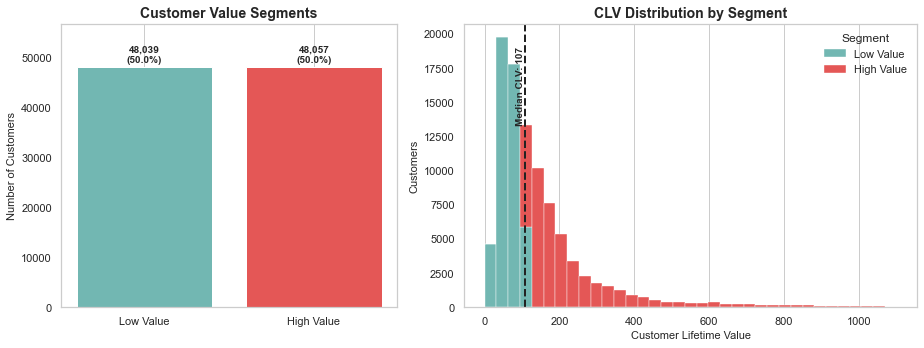

In [200]:
# High-value vs low-value customers
# Recalculate customer value from one row per order so merged rows do not inflate CLV.
customer_orders_for_value = orders_df.merge(
    customer_df[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

order_value_for_segment = order_items_df.copy()
order_value_for_segment["item_total"] = order_value_for_segment["price"] + order_value_for_segment["freight_value"]
order_value_for_segment = (
    order_value_for_segment.groupby("order_id", as_index=False)
    .agg(total_order_value=("item_total", "sum"))
)

customer_value_df = customer_orders_for_value.merge(
    order_value_for_segment,
    on="order_id",
    how="left"
)

customer_value_df = (
    customer_value_df.groupby("customer_unique_id", as_index=False)
    .agg(
        clv=("total_order_value", "sum"),
        purchase_frequency=("order_id", "nunique")
    )
)
customer_value_df["aov"] = customer_value_df["clv"] / customer_value_df["purchase_frequency"]

median_clv = customer_value_df["clv"].median()
customer_value_df["customer_segment"] = customer_value_df["clv"].apply(
    lambda x: "High Value" if x >= median_clv else "Low Value"
)

segment_summary = (
    customer_value_df.groupby("customer_segment", as_index=False)
    .agg(
        customers=("customer_unique_id", "count"),
        avg_clv=("clv", "mean"),
        total_clv=("clv", "sum")
    )
)
segment_summary["percentage"] = segment_summary["customers"] / segment_summary["customers"].sum() * 100
segment_summary["customer_segment"] = pd.Categorical(
    segment_summary["customer_segment"],
    ["Low Value", "High Value"],
    ordered=True
)
segment_summary = segment_summary.sort_values("customer_segment").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 1.35]})
colors = ["#72B7B2", "#E45756"]

axes[0].bar(
    segment_summary["customer_segment"],
    segment_summary["customers"],
    color=colors
)
axes[0].set_title("Customer Value Segments", fontsize=14, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Customers")
axes[0].grid(axis="y", alpha=0.25)
axes[0].set_ylim(0, segment_summary["customers"].max() * 1.18)

for index, row in segment_summary.iterrows():
    axes[0].text(
        index,
        row["customers"] * 1.01,
        f"{row['customers']:,}\n({row['percentage']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

clv_plot = customer_value_df[customer_value_df["clv"] <= customer_value_df["clv"].quantile(0.99)].copy()
low_values = clv_plot[clv_plot["customer_segment"] == "Low Value"]["clv"]
high_values = clv_plot[clv_plot["customer_segment"] == "High Value"]["clv"]

axes[1].hist(
    [low_values, high_values],
    bins=35,
    stacked=True,
    color=colors,
    label=["Low Value", "High Value"],
    edgecolor="white",
    linewidth=0.4
)
axes[1].axvline(median_clv, color="#222222", linestyle="--", linewidth=2)
axes[1].text(
    median_clv,
    axes[1].get_ylim()[1] * 0.92,
    f"Median CLV: {median_clv:,.0f}",
    rotation=90,
    va="top",
    ha="right",
    fontsize=10,
    fontweight="bold"
)
axes[1].set_title("CLV Distribution by Segment", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Customer Lifetime Value")
axes[1].set_ylabel("Customers")
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(title="Segment", frameon=False)

plt.tight_layout()
plt.show()

In [154]:
customer_info_df.head()

,customer_unique_id,clv,purchase_frequency,aov,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,141.90,High Value
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,27.19,Low Value
2,0000f46a3911fa3c0805444483337064,86.22,1,86.22,Low Value
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,43.62,Low Value
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,196.89,High Value


In [163]:
# Geographic details with one row per customer_unique_id
customer_geo_df = (
    customer_df
    .sort_values("customer_id")
    .drop_duplicates(subset="customer_unique_id", keep="first")
    [[
        "customer_unique_id",
        "customer_zip_code_prefix",
        "customer_city",
        "customer_state"
    ]]
)

print(customer_geo_df["customer_unique_id"].is_unique)

customer_info_df = customer_info_df.merge(
    customer_geo_df,
    on="customer_unique_id",
    how="left"
)

customer_info_df.head()

True


,customer_unique_id,clv,purchase_frequency,aov,customer_segment,customer_zip_code_prefix,customer_city,customer_state
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,141.90,High Value,7787,cajamar,SP
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,27.19,Low Value,6053,osasco,SP
2,0000f46a3911fa3c0805444483337064,86.22,1,86.22,Low Value,88115,sao jose,SC
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,43.62,Low Value,66812,belem,PA
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,196.89,High Value,18040,sorocaba,SP


In [164]:
customer_info_df.shape

(96096, 8)

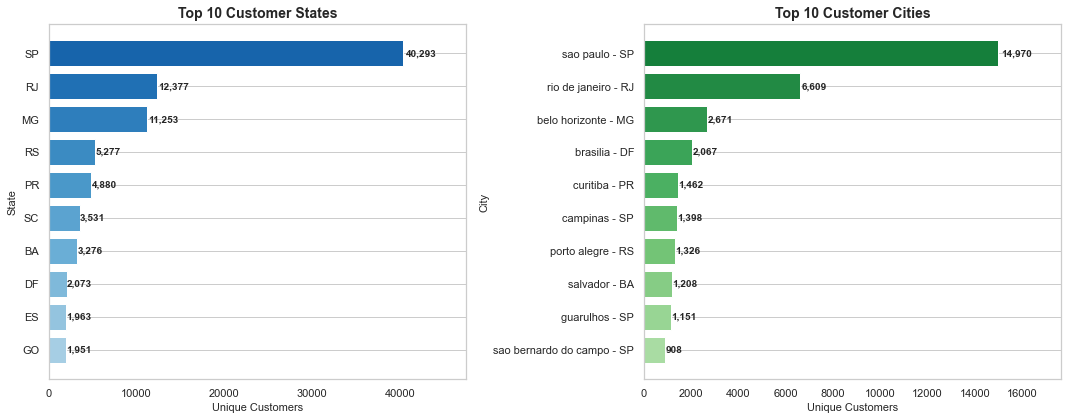

In [165]:
# Geographic distribution of customers
geo_customer_df = customer_info_df.drop_duplicates(subset="customer_unique_id").copy()

state_summary = (
    geo_customer_df["customer_state"]
    .value_counts()
    .head(10)
    .sort_values()
)

city_summary = (
    geo_customer_df.groupby(["customer_city", "customer_state"])
    .size()
    .reset_index(name="customers")
    .sort_values("customers", ascending=False)
    .head(10)
)
city_summary["city_state"] = city_summary["customer_city"] + " - " + city_summary["customer_state"]
city_summary = city_summary.sort_values("customers")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

state_colors = plt.cm.Blues([0.35 + i * 0.05 for i in range(len(state_summary))])
axes[0].barh(state_summary.index, state_summary.values, color=state_colors)
axes[0].set_title("Top 10 Customer States", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Unique Customers")
axes[0].set_ylabel("State")
axes[0].grid(axis="x", alpha=0.25)

for index, value in enumerate(state_summary.values):
    axes[0].text(value * 1.01, index, f"{value:,}", va="center", fontsize=10, fontweight="bold")
axes[0].set_xlim(0, state_summary.max() * 1.18)

city_colors = plt.cm.Greens([0.35 + i * 0.05 for i in range(len(city_summary))])
axes[1].barh(city_summary["city_state"], city_summary["customers"], color=city_colors)
axes[1].set_title("Top 10 Customer Cities", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Unique Customers")
axes[1].set_ylabel("City")
axes[1].grid(axis="x", alpha=0.25)

for index, value in enumerate(city_summary["customers"]):
    axes[1].text(value * 1.01, index, f"{value:,}", va="center", fontsize=10, fontweight="bold")
axes[1].set_xlim(0, city_summary["customers"].max() * 1.18)

plt.tight_layout()
plt.show()

### Revenue and Order Analysis

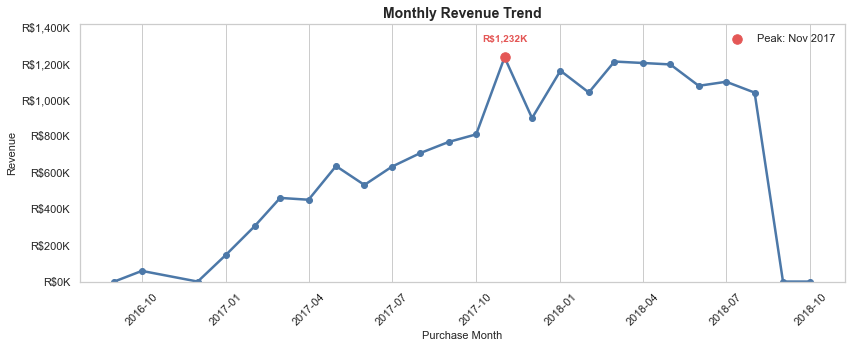

In [166]:
# Monthly revenue trends
monthly_revenue_df = (
    df.drop_duplicates(subset="order_id")
    .dropna(subset=["order_purchased_at"])
    .copy()
)

monthly_revenue_df["purchase_month"] = monthly_revenue_df["order_purchased_at"].dt.to_period("M").dt.to_timestamp()

monthly_revenue = (
    monthly_revenue_df.groupby("purchase_month", as_index=False)
    .agg(
        monthly_revenue=("total_order_value", "sum"),
        order_count=("order_id", "nunique")
    )
    .sort_values("purchase_month")
)

peak_month = monthly_revenue.loc[monthly_revenue["monthly_revenue"].idxmax()]

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_revenue["purchase_month"],
    monthly_revenue["monthly_revenue"],
    marker="o",
    linewidth=2.5,
    color="#4C78A8"
)
plt.scatter(
    peak_month["purchase_month"],
    peak_month["monthly_revenue"],
    color="#E45756",
    s=90,
    zorder=3,
    label=f"Peak: {peak_month['purchase_month'].strftime('%b %Y')}"
)
plt.title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
plt.xlabel("Purchase Month")
plt.ylabel("Revenue")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45)
plt.legend(frameon=False)

max_revenue = monthly_revenue["monthly_revenue"].max()
yticks = plt.yticks()[0]
plt.yticks(yticks, [f"R${value/1000:,.0f}K" for value in yticks])
plt.ylim(0, max_revenue * 1.15)

plt.annotate(
    f"R${peak_month['monthly_revenue']/1000:,.0f}K",
    xy=(peak_month["purchase_month"], peak_month["monthly_revenue"]),
    xytext=(0, 16),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    fontweight="bold",
    color="#E45756"
)

plt.tight_layout()
plt.show()


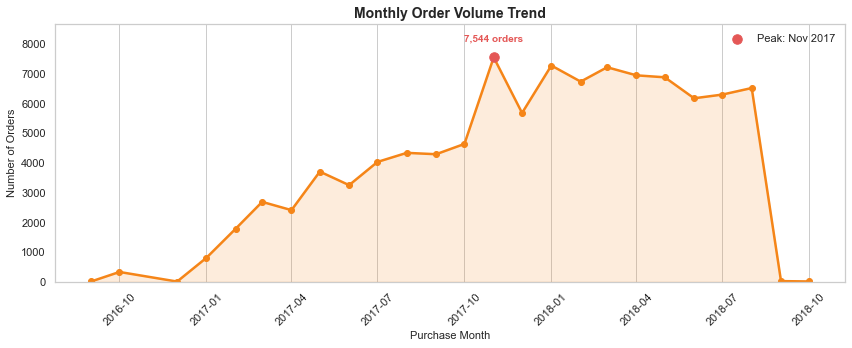

In [168]:
# Order volume trends
monthly_orders_df = (
    df.drop_duplicates(subset="order_id")
    .dropna(subset=["order_purchased_at"])
    .copy()
)

monthly_orders_df["purchase_month"] = monthly_orders_df["order_purchased_at"].dt.to_period("M").dt.to_timestamp()

monthly_orders = (
    monthly_orders_df.groupby("purchase_month", as_index=False)
    .agg(order_count=("order_id", "nunique"))
    .sort_values("purchase_month")
)

peak_order_month = monthly_orders.loc[monthly_orders["order_count"].idxmax()]

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_orders["purchase_month"],
    monthly_orders["order_count"],
    marker="o",
    linewidth=2.5,
    color="#F58518"
)
plt.fill_between(
    monthly_orders["purchase_month"],
    monthly_orders["order_count"],
    alpha=0.15,
    color="#F58518"
)
plt.scatter(
    peak_order_month["purchase_month"],
    peak_order_month["order_count"],
    color="#E45756",
    s=90,
    zorder=3,
    label=f"Peak: {peak_order_month['purchase_month'].strftime('%b %Y')}"
)

plt.title("Monthly Order Volume Trend", fontsize=14, fontweight="bold")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45)
plt.legend(frameon=False)
plt.ylim(0, monthly_orders["order_count"].max() * 1.15)

plt.annotate(
    f"{peak_order_month['order_count']:,} orders",
    xy=(peak_order_month["purchase_month"], peak_order_month["order_count"]),
    xytext=(0, 16),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    fontweight="bold",
    color="#E45756"
)

plt.tight_layout()
plt.show()


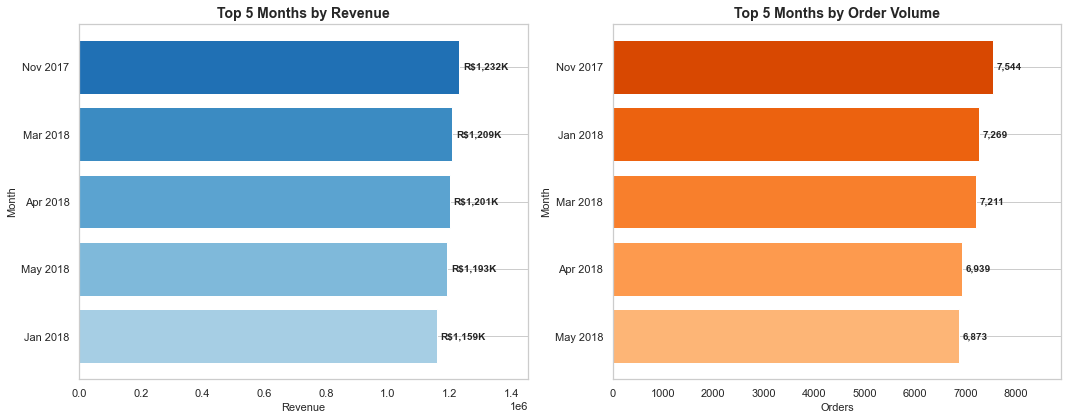

In [169]:
# Peak sales periods
sales_period_df = (
    df.drop_duplicates(subset="order_id")
    .dropna(subset=["order_purchased_at"])
    .copy()
)

sales_period_df["purchase_month"] = sales_period_df["order_purchased_at"].dt.to_period("M").dt.to_timestamp()

monthly_sales = (
    sales_period_df.groupby("purchase_month", as_index=False)
    .agg(
        revenue=("total_order_value", "sum"),
        orders=("order_id", "nunique")
    )
    .sort_values("purchase_month")
)
monthly_sales["month_label"] = monthly_sales["purchase_month"].dt.strftime("%b %Y")

peak_revenue_months = monthly_sales.nlargest(5, "revenue").sort_values("revenue")
peak_order_months = monthly_sales.nlargest(5, "orders").sort_values("orders")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

revenue_colors = plt.cm.Blues([0.35 + i * 0.1 for i in range(len(peak_revenue_months))])
axes[0].barh(peak_revenue_months["month_label"], peak_revenue_months["revenue"], color=revenue_colors)
axes[0].set_title("Top 5 Months by Revenue", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Month")
axes[0].grid(axis="x", alpha=0.25)

for index, value in enumerate(peak_revenue_months["revenue"]):
    axes[0].text(value * 1.01, index, f"R${value/1000:,.0f}K", va="center", fontsize=10, fontweight="bold")
axes[0].set_xlim(0, peak_revenue_months["revenue"].max() * 1.18)

order_colors = plt.cm.Oranges([0.35 + i * 0.1 for i in range(len(peak_order_months))])
axes[1].barh(peak_order_months["month_label"], peak_order_months["orders"], color=order_colors)
axes[1].set_title("Top 5 Months by Order Volume", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Orders")
axes[1].set_ylabel("Month")
axes[1].grid(axis="x", alpha=0.25)

for index, value in enumerate(peak_order_months["orders"]):
    axes[1].text(value * 1.01, index, f"{value:,}", va="center", fontsize=10, fontweight="bold")
axes[1].set_xlim(0, peak_order_months["orders"].max() * 1.18)

plt.tight_layout()
plt.show()


### Product Analysis


In [182]:
# Product analysis setup
product_items_df = (
    df.dropna(subset=["order_item_id", "product_category_name_english"])
    .drop_duplicates(subset=["order_id", "order_item_id", "product_id", "seller_id"])
    .copy()
)

product_items_df["item_total"] = product_items_df["price"] + product_items_df["freight_value"]

category_summary = (
    product_items_df.groupby("product_category_name_english", as_index=False)
    .agg(
        items_sold=("order_item_id", "count"),
        revenue=("item_total", "sum"),
        orders=("order_id", "nunique")
    )
)
category_summary["revenue_share"] = category_summary["revenue"] / category_summary["revenue"].sum() * 100
category_summary.head()


,product_category_name_english,items_sold,revenue,orders,revenue_share
0,agro_industry_and_commerce,212,78374.07,182,0.501500
1,air_conditioning,297,61774.19,253,0.395281
2,art,209,28247.81,202,0.180752
3,arts_and_craftmanship,24,2184.14,23,0.013976
4,audio,364,56398.94,350,0.360886


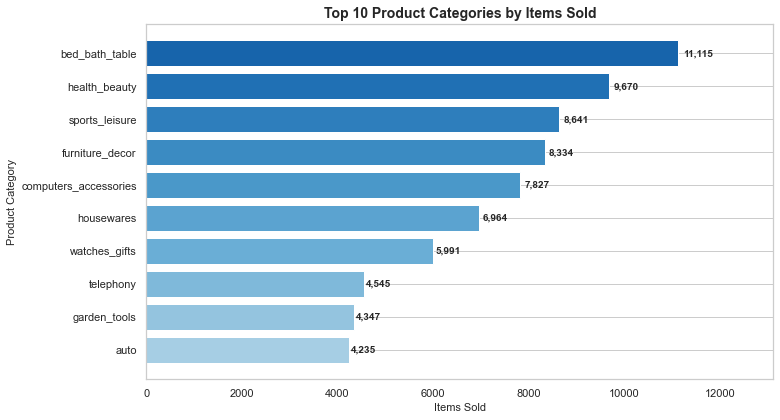

In [183]:
# Top-selling product categories
top_selling_categories = (
    category_summary
    .sort_values("items_sold", ascending=False)
    .head(10)
    .sort_values("items_sold")
)

plt.figure(figsize=(11, 6))
colors = plt.cm.Blues([0.35 + i * 0.05 for i in range(len(top_selling_categories))])
plt.barh(
    top_selling_categories["product_category_name_english"],
    top_selling_categories["items_sold"],
    color=colors
)
plt.title("Top 10 Product Categories by Items Sold", fontsize=14, fontweight="bold")
plt.xlabel("Items Sold")
plt.ylabel("Product Category")
plt.grid(axis="x", alpha=0.25)

for index, value in enumerate(top_selling_categories["items_sold"]):
    plt.text(value * 1.01, index, f"{value:,}", va="center", fontsize=10, fontweight="bold")
plt.xlim(0, top_selling_categories["items_sold"].max() * 1.18)

plt.tight_layout()
plt.show()


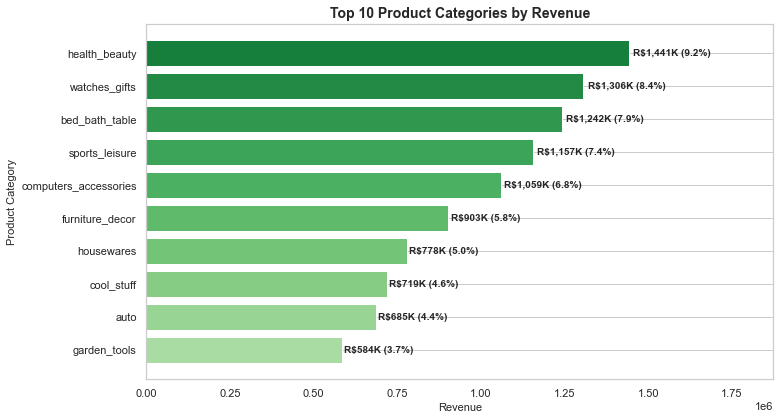

In [184]:
# Revenue contribution by category
top_revenue_categories = (
    category_summary
    .sort_values("revenue", ascending=False)
    .head(10)
    .sort_values("revenue")
)

plt.figure(figsize=(11, 6))
colors = plt.cm.Greens([0.35 + i * 0.05 for i in range(len(top_revenue_categories))])
plt.barh(
    top_revenue_categories["product_category_name_english"],
    top_revenue_categories["revenue"],
    color=colors
)
plt.title("Top 10 Product Categories by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.grid(axis="x", alpha=0.25)

for index, row in top_revenue_categories.reset_index(drop=True).iterrows():
    plt.text(
        row["revenue"] * 1.01,
        index,
        f"R${row['revenue']/1000:,.0f}K ({row['revenue_share']:.1f}%)",
        va="center",
        fontsize=10,
        fontweight="bold"
    )
plt.xlim(0, top_revenue_categories["revenue"].max() * 1.30)

plt.tight_layout()
plt.show()


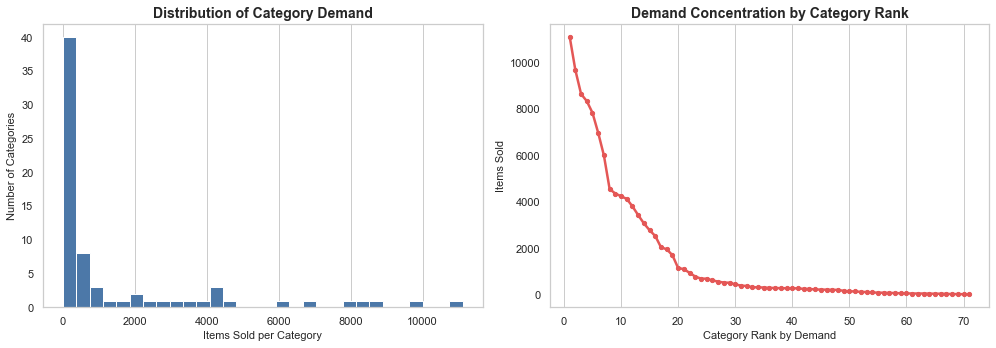

In [185]:
# Product demand distribution
category_demand = category_summary["items_sold"].sort_values(ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(category_summary["items_sold"], bins=30, color="#4C78A8", edgecolor="white")
axes[0].set_title("Distribution of Category Demand", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Items Sold per Category")
axes[0].set_ylabel("Number of Categories")
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(range(1, len(category_demand) + 1), category_demand, color="#E45756", linewidth=2.5)
axes[1].scatter(range(1, len(category_demand) + 1), category_demand, color="#E45756", s=18)
axes[1].set_title("Demand Concentration by Category Rank", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Category Rank by Demand")
axes[1].set_ylabel("Items Sold")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


### Seller Analysis


In [186]:
# Seller analysis setup
seller_items_df = (
    df.dropna(subset=["order_item_id", "seller_id"])
    .drop_duplicates(subset=["order_id", "order_item_id", "product_id", "seller_id"])
    .copy()
)

seller_items_df["item_total"] = seller_items_df["price"] + seller_items_df["freight_value"]

seller_summary = (
    seller_items_df.groupby("seller_id", as_index=False)
    .agg(
        revenue=("item_total", "sum"),
        items_sold=("order_item_id", "count"),
        orders=("order_id", "nunique"),
        seller_state=("seller_state", "first"),
        seller_city=("seller_city", "first")
    )
)
seller_summary["revenue_share"] = seller_summary["revenue"] / seller_summary["revenue"].sum() * 100
seller_summary["seller_short_id"] = seller_summary["seller_id"].str[:8]
seller_summary.head()


,seller_id,revenue,items_sold,orders,seller_state,seller_city,revenue_share,seller_short_id
0,0015a82c2db000af6aaaf3ae2ecb0532,2748.06,3,3,SP,santo andre,0.017345,0015a82c
1,001cca7ae9ae17fb1caed9dfb1094831,33934.17,239,200,ES,cariacica,0.214183,001cca7a
2,001e6ad469a905060d959994f1b41e4f,267.94,1,1,RJ,sao goncalo,0.001691,001e6ad4
3,002100f778ceb8431b7a1020ff7ab48f,2028.16,55,51,SP,franca,0.012801,002100f7
4,003554e2dce176b5555353e4f3555ac8,139.38,1,1,GO,goiania,0.000880,003554e2


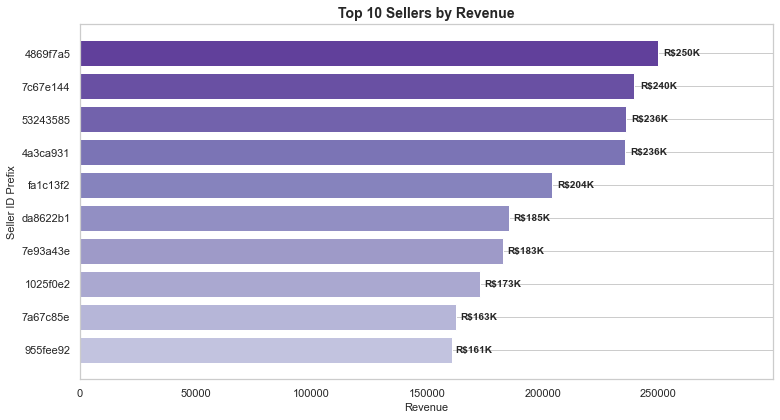

In [187]:
# Top-performing sellers
top_sellers = (
    seller_summary
    .sort_values("revenue", ascending=False)
    .head(10)
    .sort_values("revenue")
)

plt.figure(figsize=(11, 6))
colors = plt.cm.Purples([0.35 + i * 0.05 for i in range(len(top_sellers))])
plt.barh(top_sellers["seller_short_id"], top_sellers["revenue"], color=colors)
plt.title("Top 10 Sellers by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Revenue")
plt.ylabel("Seller ID Prefix")
plt.grid(axis="x", alpha=0.25)

for index, row in top_sellers.reset_index(drop=True).iterrows():
    plt.text(
        row["revenue"] * 1.01,
        index,
        f"R${row['revenue']/1000:,.0f}K",
        va="center",
        fontsize=10,
        fontweight="bold"
    )
plt.xlim(0, top_sellers["revenue"].max() * 1.20)

plt.tight_layout()
plt.show()


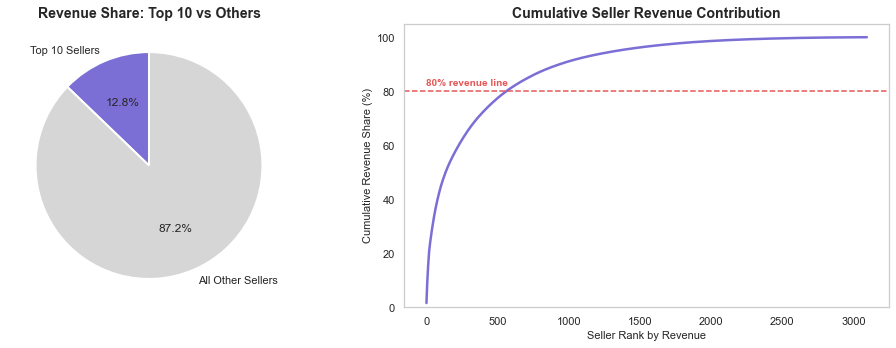

In [188]:
# Seller contribution to revenue
seller_contribution = seller_summary.sort_values("revenue", ascending=False).copy()
seller_contribution["cumulative_revenue_share"] = seller_contribution["revenue"].cumsum() / seller_contribution["revenue"].sum() * 100
seller_contribution["seller_rank"] = range(1, len(seller_contribution) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_10_share = seller_contribution.head(10)["revenue"].sum() / seller_contribution["revenue"].sum() * 100
remaining_share = 100 - top_10_share
axes[0].pie(
    [top_10_share, remaining_share],
    labels=["Top 10 Sellers", "All Other Sellers"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#7B6FD6", "#D6D6D6"],
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[0].set_title("Revenue Share: Top 10 vs Others", fontsize=14, fontweight="bold")

axes[1].plot(
    seller_contribution["seller_rank"],
    seller_contribution["cumulative_revenue_share"],
    color="#7B6FD6",
    linewidth=2.5
)
axes[1].axhline(80, color="#E45756", linestyle="--", linewidth=1.5)
axes[1].set_title("Cumulative Seller Revenue Contribution", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Seller Rank by Revenue")
axes[1].set_ylabel("Cumulative Revenue Share (%)")
axes[1].grid(alpha=0.25)
axes[1].set_ylim(0, 105)
axes[1].text(1, 82, "80% revenue line", color="#E45756", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


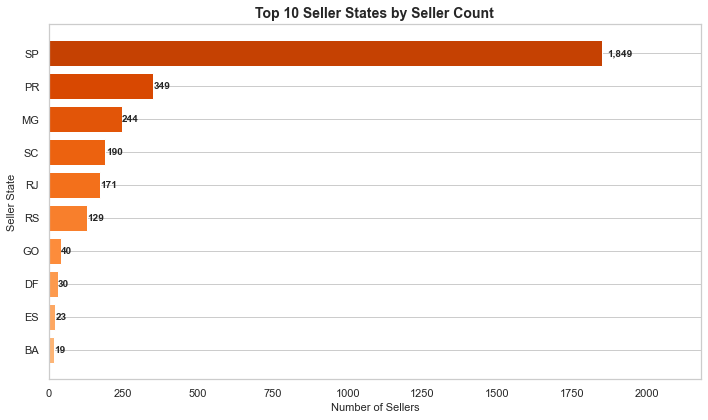

In [189]:
# Seller distribution
seller_state_distribution = (
    seller_summary.groupby("seller_state", as_index=False)
    .agg(
        sellers=("seller_id", "nunique"),
        revenue=("revenue", "sum")
    )
    .sort_values("sellers", ascending=False)
    .head(10)
    .sort_values("sellers")
)

plt.figure(figsize=(10, 6))
colors = plt.cm.Oranges([0.35 + i * 0.05 for i in range(len(seller_state_distribution))])
plt.barh(seller_state_distribution["seller_state"], seller_state_distribution["sellers"], color=colors)
plt.title("Top 10 Seller States by Seller Count", fontsize=14, fontweight="bold")
plt.xlabel("Number of Sellers")
plt.ylabel("Seller State")
plt.grid(axis="x", alpha=0.25)

for index, value in enumerate(seller_state_distribution["sellers"]):
    plt.text(value * 1.01, index, f"{value:,}", va="center", fontsize=10, fontweight="bold")
plt.xlim(0, seller_state_distribution["sellers"].max() * 1.18)

plt.tight_layout()
plt.show()


### Review and Satisfaction Analysis


In [190]:
# Review and satisfaction analysis setup
review_df = (
    df.drop_duplicates(subset="order_id")
    .dropna(subset=["review_score"])
    .copy()
)

review_df["review_score"] = review_df["review_score"].astype(int)
review_df["is_dissatisfied"] = review_df["review_score"] <= 2
review_df.head()


,order_id,customer_id,order_status,order_purchased_at,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,item_total,total_order_value,delivery_days,item_count,is_dissatisfied
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-12 03:43:48,9350.0,maua,SP,housewares,38.71,116.13,8.0,3,False
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,2018-08-08 18:37:50,31570.0,belo horizonte,SP,perfumery,141.46,141.46,13.0,1,False
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,2018-08-22 19:07:58,14840.0,guariba,SP,auto,179.12,179.12,9.0,1,False
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,2017-12-05 19:21:58,31842.0,belo horizonte,MG,pet_shop,72.20,72.20,13.0,1,False
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,2018-02-18 13:02:51,8752.0,mogi das cruzes,SP,stationery,28.62,28.62,2.0,1,False


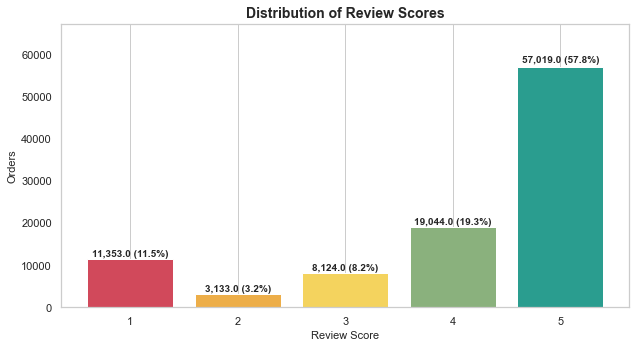

In [191]:
# Distribution of review scores
review_score_counts = (
    review_df["review_score"]
    .value_counts()
    .reindex([1, 2, 3, 4, 5])
    .reset_index()
)
review_score_counts.columns = ["review_score", "orders"]
review_score_counts["percentage"] = review_score_counts["orders"] / review_score_counts["orders"].sum() * 100

plt.figure(figsize=(9, 5))
colors = ["#D1495B", "#EDAE49", "#F4D35E", "#8AB17D", "#2A9D8F"]
plt.bar(review_score_counts["review_score"], review_score_counts["orders"], color=colors)
plt.title("Distribution of Review Scores", fontsize=14, fontweight="bold")
plt.xlabel("Review Score")
plt.ylabel("Orders")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis="y", alpha=0.25)

for index, row in review_score_counts.iterrows():
    plt.text(
        row["review_score"],
        row["orders"] * 1.01,
        f"{row['orders']:,} ({row['percentage']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )
plt.ylim(0, review_score_counts["orders"].max() * 1.18)

plt.tight_layout()
plt.show()


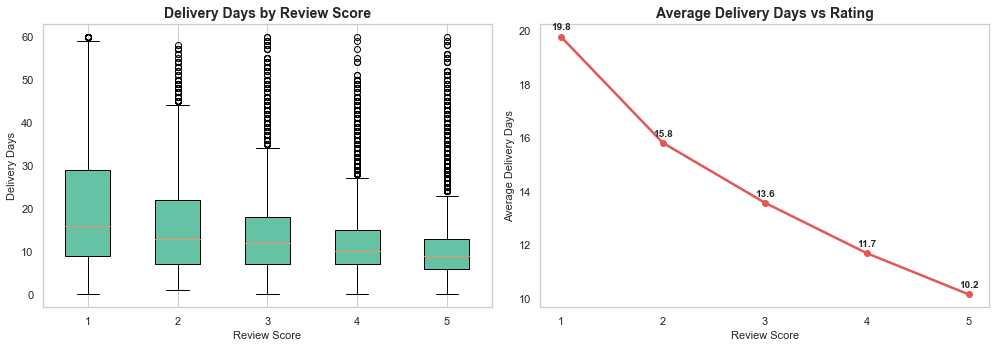

In [192]:
# Relationship between delivery time and ratings
delivery_review_df = review_df.dropna(subset=["delivery_days"]).copy()
delivery_review_df = delivery_review_df[delivery_review_df["delivery_days"].between(0, 60)]

avg_delivery_by_score = (
    delivery_review_df.groupby("review_score", as_index=False)
    .agg(avg_delivery_days=("delivery_days", "mean"))
)

delivery_by_score = [
    delivery_review_df.loc[delivery_review_df["review_score"] == score, "delivery_days"]
    for score in [1, 2, 3, 4, 5]
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(delivery_by_score, labels=[1, 2, 3, 4, 5], patch_artist=True)
axes[0].set_title("Delivery Days by Review Score", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Delivery Days")
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(
    avg_delivery_by_score["review_score"],
    avg_delivery_by_score["avg_delivery_days"],
    marker="o",
    linewidth=2.5,
    color="#E45756"
)
axes[1].set_title("Average Delivery Days vs Rating", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Review Score")
axes[1].set_ylabel("Average Delivery Days")
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].grid(alpha=0.25)

for _, row in avg_delivery_by_score.iterrows():
    axes[1].text(
        row["review_score"],
        row["avg_delivery_days"] + 0.25,
        f"{row['avg_delivery_days']:.1f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


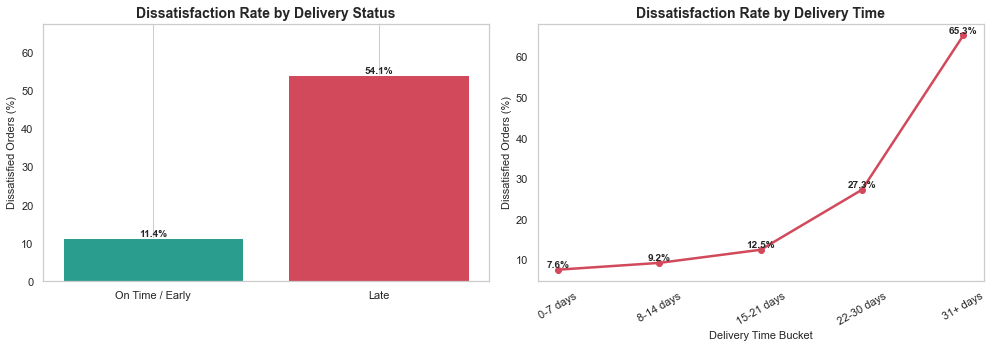

In [193]:
# Identification of dissatisfaction patterns
dissatisfaction_df = review_df.copy()
dissatisfaction_df["late_delivery"] = dissatisfaction_df["order_delivered_customer_date"] > dissatisfaction_df["order_estimated_delivery_date"]
dissatisfaction_df["delivery_bucket"] = pd.cut(
    dissatisfaction_df["delivery_days"],
    bins=[-1, 7, 14, 21, 30, 1000],
    labels=["0-7 days", "8-14 days", "15-21 days", "22-30 days", "31+ days"]
)

late_summary = (
    dissatisfaction_df.groupby("late_delivery", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        dissatisfied_orders=("is_dissatisfied", "sum")
    )
)
late_summary["dissatisfaction_rate"] = late_summary["dissatisfied_orders"] / late_summary["orders"] * 100
late_summary["delivery_status"] = late_summary["late_delivery"].map({False: "On Time / Early", True: "Late"})

bucket_summary = (
    dissatisfaction_df.dropna(subset=["delivery_bucket"])
    .groupby("delivery_bucket", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        dissatisfied_orders=("is_dissatisfied", "sum")
    )
)
bucket_summary["dissatisfaction_rate"] = bucket_summary["dissatisfied_orders"] / bucket_summary["orders"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(late_summary["delivery_status"], late_summary["dissatisfaction_rate"], color=["#2A9D8F", "#D1495B"])
axes[0].set_title("Dissatisfaction Rate by Delivery Status", fontsize=14, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Dissatisfied Orders (%)")
axes[0].grid(axis="y", alpha=0.25)
for index, row in late_summary.iterrows():
    axes[0].text(index, row["dissatisfaction_rate"] + 0.5, f"{row['dissatisfaction_rate']:.1f}%", ha="center", fontsize=10, fontweight="bold")
axes[0].set_ylim(0, late_summary["dissatisfaction_rate"].max() * 1.25)

axes[1].plot(
    bucket_summary["delivery_bucket"].astype(str),
    bucket_summary["dissatisfaction_rate"],
    marker="o",
    linewidth=2.5,
    color="#D1495B"
)
axes[1].set_title("Dissatisfaction Rate by Delivery Time", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Delivery Time Bucket")
axes[1].set_ylabel("Dissatisfied Orders (%)")
axes[1].grid(alpha=0.25)
axes[1].tick_params(axis="x", rotation=30)
for index, row in bucket_summary.iterrows():
    axes[1].text(index, row["dissatisfaction_rate"] + 0.5, f"{row['dissatisfaction_rate']:.1f}%", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


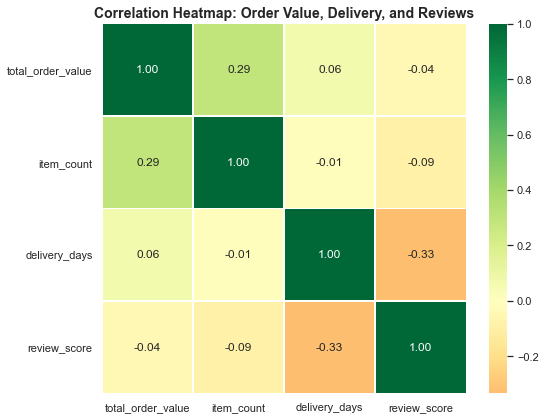

In [194]:
# Correlation heatmap for order-level metrics
order_metric_df = (
    df.drop_duplicates(subset="order_id")
    .copy()
)

heatmap_cols = ["total_order_value", "item_count", "delivery_days", "review_score"]
order_metric_df = order_metric_df[heatmap_cols].dropna()
order_metric_df["review_score"] = order_metric_df["review_score"].astype(int)

correlation_matrix = order_metric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Correlation Heatmap: Order Value, Delivery, and Reviews", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## Step 7: Business Insights and Recommendations

### Top revenue-driving factors

- Health and beauty is the top revenue category with about with Rs.1.44k revenue.
- Watches and gifts is the second strongest revenue category with about Rs.1.31M revenue.
- Bed bath table sells the most items and is also one of the top revenue categories.
- November 2017 is the peak sales month with about R$1.18M revenue and 7,544 orders.
- The top 10 sellers contribute about 12.8% of total seller revenue.

### Customer behavior patterns

- The dataset has 96,096 unique customers.
- Most customers are new customers.
- Only about 3.1% of customers are repeat customers.
- Sao Paulo is the biggest customer state with 40,296 unique customers.
- Sao Paulo city is the biggest customer city with 14,974 unique customers.

### Operational inefficiencies

- Late deliveries create much higher dissatisfaction.
- On-time or early deliveries have about 11.3% dissatisfied orders.
- Late deliveries have about 54.0% dissatisfied orders.
- The average review score for late deliveries is only 2.57.
- One-star reviews have the longest average delivery time at about 20.9 days.

### Strategic recommendations

- Focus promotions and inventory on the top revenue categories.
- Create retention offers because repeat customers are very low.
- Improve delivery speed because late delivery strongly reduces review scores.
- Track seller performance using revenue, delivery time, and review score together.
- Give more logistics and marketing focus to high-demand states like SP, RJ, and MG.
